<a href="https://colab.research.google.com/github/NitinKarthik01/AIML_MSIS/blob/main/prevent_overfitting_using_Pruning_and_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#***Regularization Techniques for Logistic Regression***

NO MISSING VALUES

Categorical Columns (0):
None

Numerical Columns (31):
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']

LOGISTIC REGRESSION

Training Data
Accuracy  : 0.9673366834170855
Precision : 0.9684120154843336
Recall    : 0.9673366834170855
F1 Score  : 0.9670636748565565

Testing Data
Accuracy  : 0.9649122807017544
Precision : 0.9655600866573213
Recall    : 0.9649122807017544
F1 Score  : 0.9646560514550161

Accuracy Gap : 0.0024244027153310643
 

R

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap,Training F1,Testing F1
0,Logistic Regression,0.967337,0.964912,0.002424,0.967064,0.964656
1,Ridge L2,0.932161,0.953216,-0.021056,0.930676,0.952679
2,Lasso L1,0.927136,0.918129,0.009007,0.925994,0.917531


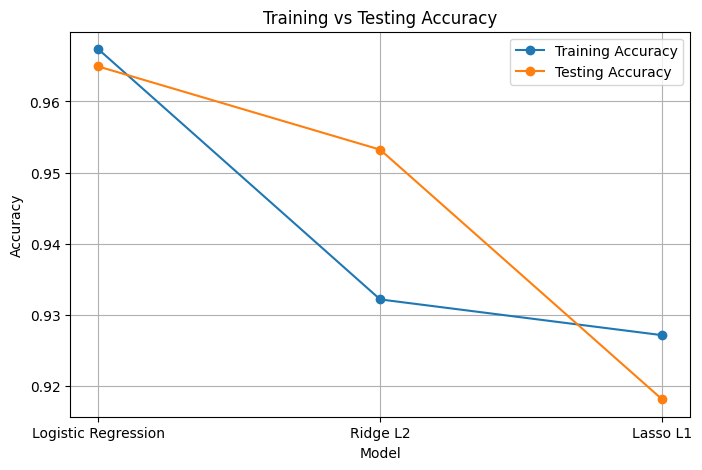

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


cancer = load_breast_cancer(as_frame=True)

df = cancer.frame

missing = df.isnull().sum()

if missing.sum() == 0:
    print("NO MISSING VALUES")
else:
    display(missing)


categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print(f"\nCategorical Columns ({len(categorical_cols)}):")
print(categorical_cols if categorical_cols else "None")

print(f"\nNumerical Columns ({len(numerical_cols)}):")
print(numerical_cols if numerical_cols else "None")


x = cancer.data
y = cancer.target

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=42
)


minmax = MinMaxScaler()

x_train_scaled = minmax.fit_transform(x_train)
x_test_scaled = minmax.transform(x_test)


print("\n==========================================")
print("LOGISTIC REGRESSION")
print("==========================================")

model1 = LogisticRegression(
    max_iter=500
)

model1.fit(x_train_scaled, y_train)

pred_train = model1.predict(x_train_scaled)
pred_test = model1.predict(x_test_scaled)

print("\nTraining Data")
print("Accuracy  :", accuracy_score(y_train, pred_train))
print("Precision :", precision_score(y_train, pred_train, average="weighted"))
print("Recall    :", recall_score(y_train, pred_train, average="weighted"))
print("F1 Score  :", f1_score(y_train, pred_train, average="weighted"))

print("\nTesting Data")
print("Accuracy  :", accuracy_score(y_test, pred_test))
print("Precision :", precision_score(y_test, pred_test, average="weighted"))
print("Recall    :", recall_score(y_test, pred_test, average="weighted"))
print("F1 Score  :", f1_score(y_test, pred_test, average="weighted"))

print("\nAccuracy Gap :", accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test))
print(" ")

if (accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test)) > 0.05:
        print("\nResult: Possible Overfitting")
else:
    print("\nResult: No Significant Overfitting")



print("\n==========================================")
print("RIDGE LOGISTIC REGRESSION - L2")
print("==========================================")

model1_ridge = LogisticRegression(
    penalty="l2",   # penalty = l2 means it uses ridge regularization
    C=0.1,          # for controlling regularization strength we use that -> C is low means strong regulairzation will be performed, C is high means low regulairzation will be performed
    max_iter=500
)

model1_ridge.fit(x_train_scaled, y_train)

pred_train_ridge = model1_ridge.predict(x_train_scaled)
pred_test_ridge = model1_ridge.predict(x_test_scaled)

print("\nTraining Data")
print("Accuracy  :", accuracy_score(y_train, pred_train_ridge))
print("Precision :", precision_score(y_train, pred_train_ridge, average="weighted"))
print("Recall    :", recall_score(y_train, pred_train_ridge, average="weighted"))
print("F1 Score  :", f1_score(y_train, pred_train_ridge, average="weighted"))

print("\nTesting Data")
print("Accuracy  :", accuracy_score(y_test, pred_test_ridge))
print("Precision :", precision_score(y_test, pred_test_ridge, average="weighted"))
print("Recall    :", recall_score(y_test, pred_test_ridge, average="weighted"))
print("F1 Score  :", f1_score(y_test, pred_test_ridge, average="weighted"))

print("\nAccuracy Gap :",accuracy_score(y_train, pred_train_ridge) - accuracy_score(y_test, pred_test_ridge))
print(" ")


if (accuracy_score(y_train, pred_train_ridge) - accuracy_score(y_test, pred_test_ridge)) > 0.05:
        print("\nResult: Possible Overfitting")
else:
    print("\nResult: No Significant Overfitting")


print("\n==========================================")
print("LASSO LOGISTIC REGRESSION - L1")
print("==========================================")

model1_lasso = LogisticRegression(
    penalty="l1",        # penalty = l1 means it uses lasso regularization
    solver="liblinear",  # The solver is the optimization algorithm that Logistic Regression uses to find the best coefficients -> You need this here because liblinear supports L1 regularization for Logistic Regression.
    C=0.1,
    max_iter=500
)

model1_lasso.fit(x_train_scaled, y_train)

pred_train_lasso = model1_lasso.predict(x_train_scaled)
pred_test_lasso = model1_lasso.predict(x_test_scaled)

print("\nTraining Data")
print("Accuracy  :", accuracy_score(y_train, pred_train_lasso))
print("Precision :", precision_score(y_train, pred_train_lasso, average="weighted"))
print("Recall    :", recall_score(y_train, pred_train_lasso, average="weighted"))
print("F1 Score  :", f1_score(y_train, pred_train_lasso, average="weighted"))

print("\nTesting Data")
print("Accuracy  :", accuracy_score(y_test, pred_test_lasso))
print("Precision :", precision_score(y_test, pred_test_lasso, average="weighted"))
print("Recall    :", recall_score(y_test, pred_test_lasso, average="weighted"))
print("F1 Score  :", f1_score(y_test, pred_test_lasso, average="weighted"))

print("\nAccuracy Gap :", accuracy_score(y_train, pred_train_lasso) - accuracy_score(y_test, pred_test_lasso))
print(" ")

if (accuracy_score(y_train, pred_train_lasso) - accuracy_score(y_test, pred_test_lasso)) > 0.05:
        print("\nResult: Possible Overfitting")
else:
    print("\nResult: No Significant Overfitting")


comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Ridge L2",
        "Lasso L1"
    ],
    "Training Accuracy": [
        accuracy_score(y_train, pred_train),
        accuracy_score(y_train, pred_train_ridge),
        accuracy_score(y_train, pred_train_lasso)
    ],
    "Testing Accuracy": [
        accuracy_score(y_test, pred_test),
        accuracy_score(y_test, pred_test_ridge),
        accuracy_score(y_test, pred_test_lasso)
    ],
    "Accuracy Gap": [
        accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test),
        accuracy_score(y_train, pred_train_ridge) - accuracy_score(y_test, pred_test_ridge),
        accuracy_score(y_train, pred_train_lasso) - accuracy_score(y_test, pred_test_lasso)
    ],
    "Training F1": [
        f1_score(y_train, pred_train, average="weighted"),
        f1_score(y_train, pred_train_ridge, average="weighted"),
        f1_score(y_train, pred_train_lasso, average="weighted")
    ],
    "Testing F1": [
        f1_score(y_test, pred_test, average="weighted"),
        f1_score(y_test, pred_test_ridge, average="weighted"),
        f1_score(y_test, pred_test_lasso, average="weighted")
    ]
})



print("\n==========================================")
print("FINAL COMPARISON")
print("==========================================")

display(comparison)

print(" ")
print(" ")
print(" ")

plt.figure(figsize=(8, 5))

plt.plot(
    comparison["Model"],
    comparison["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    comparison["Model"],
    comparison["Testing Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.grid()
plt.show()

#***Pruning Techniques for Decision Tree***

CCP stands for Cost-Complexity Pruning.

A Decision Tree keeps creating branches to improve its predictions.

Some branches may only help with a few training samples and can cause overfitting.

ccp_alpha tells the tree: "Is this extra branch worth keeping?"

ccp_alpha = 0
     ->
No pruning
     ->
Large/complex tree
     ->
Higher chance of overfitting



UNRESTRICTED DECISION TREE
Training Accuracy : 1.0
Testing Accuracy  : 0.9415204678362573
Accuracy Gap      : 0.05847953216374269
Result: Possible Overfitting

PRE-PRUNED DECISION TREE
Training Accuracy : 0.9798994974874372
Testing Accuracy  : 0.9707602339181286
Accuracy Gap      : 0.009139263569308609
Result: No Significant Overfitting

BEST POST-PRUNING ALPHA
Best ccp_alpha : 0.0049148318490037

POST-PRUNED DECISION TREE
Training Accuracy : 0.9899497487437185
Testing Accuracy  : 0.9649122807017544
Accuracy Gap      : 0.02503746804196416
Result: No Significant Overfitting

FINAL COMPARISON


,Model,Training Accuracy,Testing Accuracy,Accuracy Gap
0,Unrestricted,1.000000,0.941520,0.058480
1,Pre-Pruned,0.979899,0.970760,0.009139
2,Post-Pruned,0.989950,0.964912,0.025037


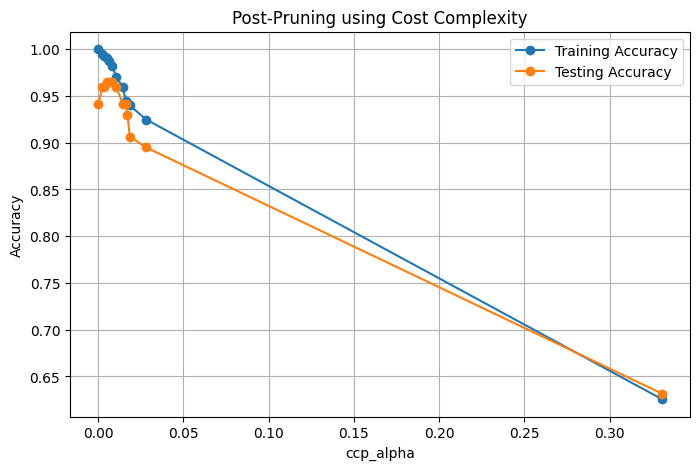

In [65]:
from sklearn.tree import DecisionTreeClassifier

model2_nostop = DecisionTreeClassifier(random_state=42)

model2_nostop.fit(x_train, y_train)

pred_train_nostop = model2_nostop.predict(x_train)
pred_test_nostop = model2_nostop.predict(x_test)

print("==========================================")
print("UNRESTRICTED DECISION TREE")
print("==========================================")

print("Training Accuracy :", accuracy_score(y_train, pred_train_nostop))
print("Testing Accuracy  :", accuracy_score(y_test, pred_test_nostop))
print("Accuracy Gap      :", accuracy_score(y_train, pred_train_nostop) - accuracy_score(y_test, pred_test_nostop))

if (accuracy_score(y_train, pred_train_nostop) - accuracy_score(y_test, pred_test_nostop)) > 0.05:
    print("Result: Possible Overfitting")
else:
    print("Result: No Significant Overfitting")



model2 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model2.fit(x_train, y_train)

pred_train = model2.predict(x_train)
pred_test = model2.predict(x_test)

print("\n==========================================")
print("PRE-PRUNED DECISION TREE")
print("==========================================")

print("Training Accuracy :", accuracy_score(y_train, pred_train))
print("Testing Accuracy  :", accuracy_score(y_test, pred_test))
print("Accuracy Gap      :", accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test))

if (accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test)) > 0.05:
    print("Result: Possible Overfitting")
else:
    print("Result: No Significant Overfitting")




path = model2_nostop.cost_complexity_pruning_path(x_train, y_train)

ccp_alphas = path.ccp_alphas  # extract all possible alpha values like [0.0, 0.002, 0.005, 0.008, 0.015, 0.025, ...] -> Each value represents a different amount of pruning.

train_scores = []
test_scores = []

for alpha in ccp_alphas:                # for every ccp values we train the model and check training accuracy and testing accuracy for it
    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )

    model.fit(x_train, y_train)

    train_scores.append(model.score(x_train, y_train))
    test_scores.append(model.score(x_test, y_test))


best_alpha = ccp_alphas[np.argmax(test_scores)]    # we take the value at index for which we got maximum testing accuracy, that is the best ccp alpha value

print("\n==========================================")
print("BEST POST-PRUNING ALPHA")
print("==========================================")

print("Best ccp_alpha :", best_alpha)


model2_post = DecisionTreeClassifier(              # with the best ccp alpha value that is gioving the best testing accuracy we train the model again and find the accuracy of training and testing
    random_state=42,
    ccp_alpha=best_alpha
)

model2_post.fit(x_train, y_train)

pred_train_post = model2_post.predict(x_train)
pred_test_post = model2_post.predict(x_test)

print("\n==========================================")
print("POST-PRUNED DECISION TREE")
print("==========================================")

print("Training Accuracy :", accuracy_score(y_train, pred_train_post))
print("Testing Accuracy  :", accuracy_score(y_test, pred_test_post))
print("Accuracy Gap      :", accuracy_score(y_train, pred_train_post) - accuracy_score(y_test, pred_test_post))


if (accuracy_score(y_train, pred_train_post) - accuracy_score(y_test, pred_test_post)) > 0.05:
    print("Result: Possible Overfitting")
else:
    print("Result: No Significant Overfitting")


comparison = pd.DataFrame({
    "Model": ["Unrestricted", "Pre-Pruned", "Post-Pruned"],
    "Training Accuracy": [
        accuracy_score(y_train, pred_train_nostop),
        accuracy_score(y_train, pred_train),
        accuracy_score(y_train, pred_train_post)
    ],
    "Testing Accuracy": [
        accuracy_score(y_test, pred_test_nostop),
        accuracy_score(y_test, pred_test),
        accuracy_score(y_test, pred_test_post)
    ],
    "Accuracy Gap": [
        accuracy_score(y_train, pred_train_nostop) - accuracy_score(y_test, pred_test_nostop),
        accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test),
        accuracy_score(y_train, pred_train_post) - accuracy_score(y_test, pred_test_post)
    ]
})

print("\n==========================================")
print("FINAL COMPARISON")
print("==========================================")

display(comparison)

print(" ")
print(" ")
print(" ")
plt.figure(figsize=(8, 5))

plt.plot(ccp_alphas, train_scores, marker="o", label="Training Accuracy")
plt.plot(ccp_alphas, test_scores, marker="o", label="Testing Accuracy")

plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Post-Pruning using Cost Complexity")
plt.legend()
plt.grid()
plt.show()

print(" ")
print(" ")
print(" ")


#***Regularization Techniques for Linear REgression***


LINEAR REGRESSION

Training
MSE : 2924.0463790726394
MAE : 44.0978349926357
R2  : 0.5244124363545944

Testing
MSE : 2821.7509810013103
MAE : 41.919378456792735
R2  : 0.4772897164322618

R2 Gap : 0.047122719922332634

RIDGE REGRESSION

Training
MSE : 2943.1915474190537
MAE : 44.33030954802198
R2  : 0.5212985308999416

Testing
MSE : 2817.491144307545
MAE : 41.85665063904649
R2  : 0.4780788223672442

R2 Gap : 0.04321970853269741

LASSO REGRESSION

Training
MSE : 2956.3347209402905
MAE : 44.51791796012213
R2  : 0.5191608322921937

Testing
MSE : 2784.334385980127
MAE : 41.8643951462288
R2  : 0.48422088758285065

R2 Gap : 0.03493994470934303

FINAL COMPARISON


,Model,Training R2,Testing R2,R2 Gap,Testing MSE
0,Linear Regression,0.524412,0.477290,0.047123,2821.750981
1,Ridge Regression,0.521299,0.478079,0.043220,2817.491144
2,Lasso Regression,0.519161,0.484221,0.034940,2784.334386


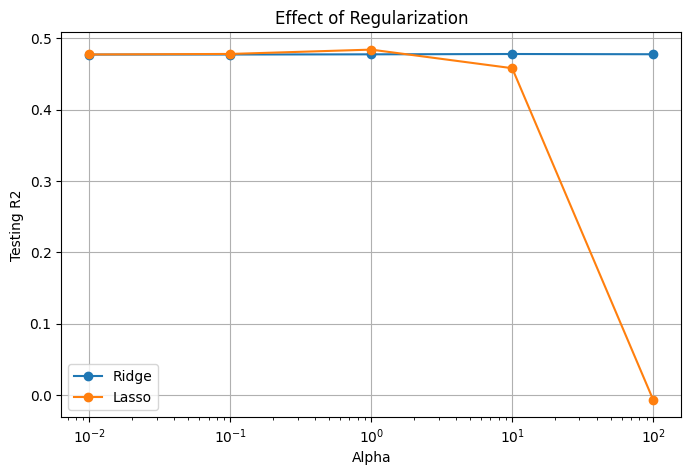

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


data = load_diabetes(as_frame=True)

x = data.data
y = data.target

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.3,
    random_state=42
)


scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


linear = LinearRegression()

linear.fit(x_train_scaled, y_train)

linear_train = linear.predict(x_train_scaled)
linear_test = linear.predict(x_test_scaled)


ridge = Ridge(alpha=10)

ridge.fit(x_train_scaled, y_train)

ridge_train = ridge.predict(x_train_scaled)
ridge_test = ridge.predict(x_test_scaled)


lasso = Lasso(alpha=1)

lasso.fit(x_train_scaled, y_train)

lasso_train = lasso.predict(x_train_scaled)
lasso_test = lasso.predict(x_test_scaled)


def evaluate(name, y_train, train_pred, y_test, test_pred):

    print("\n================================")
    print(name)
    print("================================")

    print("\nTraining")
    print("MSE :", mean_squared_error(y_train, train_pred))
    print("MAE :", mean_absolute_error(y_train, train_pred))
    print("R2  :", r2_score(y_train, train_pred))

    print("\nTesting")
    print("MSE :", mean_squared_error(y_test, test_pred))
    print("MAE :", mean_absolute_error(y_test, test_pred))
    print("R2  :", r2_score(y_test, test_pred))

    print("\nR2 Gap :", r2_score(y_train, train_pred) - r2_score(y_test, test_pred))


evaluate(
    "LINEAR REGRESSION",
    y_train, linear_train,
    y_test, linear_test
)

evaluate(
    "RIDGE REGRESSION",
    y_train, ridge_train,
    y_test, ridge_test
)

evaluate(
    "LASSO REGRESSION",
    y_train, lasso_train,
    y_test, lasso_test
)


comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "Training R2": [
        r2_score(y_train, linear_train),
        r2_score(y_train, ridge_train),
        r2_score(y_train, lasso_train)
    ],

    "Testing R2": [
        r2_score(y_test, linear_test),
        r2_score(y_test, ridge_test),
        r2_score(y_test, lasso_test)
    ],

    "R2 Gap": [
        r2_score(y_train, linear_train) - r2_score(y_test, linear_test),
        r2_score(y_train, ridge_train) - r2_score(y_test, ridge_test),
        r2_score(y_train, lasso_train) - r2_score(y_test, lasso_test)
    ],

    "Testing MSE": [
        mean_squared_error(y_test, linear_test),
        mean_squared_error(y_test, ridge_test),
        mean_squared_error(y_test, lasso_test)
    ]
})


print("\n================================")
print("FINAL COMPARISON")
print("================================")

display(comparison)

print(" ")
print(" ")
print(" ")
alphas = [0.01, 0.1, 1, 10, 100]

ridge_scores = []
lasso_scores = []

for alpha in alphas:

    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(x_train_scaled, y_train)

    ridge_scores.append(
        r2_score(y_test, ridge_model.predict(x_test_scaled))
    )

    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(x_train_scaled, y_train)

    lasso_scores.append(
        r2_score(y_test, lasso_model.predict(x_test_scaled))
    )


plt.figure(figsize=(8, 5))

plt.plot(alphas, ridge_scores, marker="o", label="Ridge")
plt.plot(alphas, lasso_scores, marker="o", label="Lasso")

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Testing R2")
plt.title("Effect of Regularization")
plt.legend()
plt.grid()
plt.show()